# Set up

In [1]:
#every other package used should be included in Collabs native workspace
!pip install pysal


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


First, I will read in the data then splice it to only keep Lima.

In [2]:
from libpysal.graph import Graph
import geopandas as gpd
import esda

#used in the last few chunks to check the differences in Moarn I between KNN and Queen clasification 
import pandas as pd
from sklearn.metrics import cohen_kappa_score 



LinkPeru="https://github.com/MarkGScott960/DACCS690C_HW1/raw/main/PeruMaps.gpkg"
peru=gpd.read_file(LinkPeru,layer='good_geom')
lima=peru[peru['DEPARTAMENTO'].str.lower() == "lima"] #using .lower() to avoid any case changes


c:\Users\markg\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Now lets verify that the map is projected, and if not project it.

In [3]:
if not lima.crs.is_projected:
    lima=lima.to_crs(5387)
    print("Map is now projected")
else:
    print("Map is projected")

Map is now projected


# Queen & KNN Algorithm

Now lets make the LISA map using the **Queen** criterion:

In [4]:
limaQueen = Graph.build_contiguity(lima, rook =False) # build graph object
limaQueen=limaQueen.transform("r") #normalize it!

<Axes: >

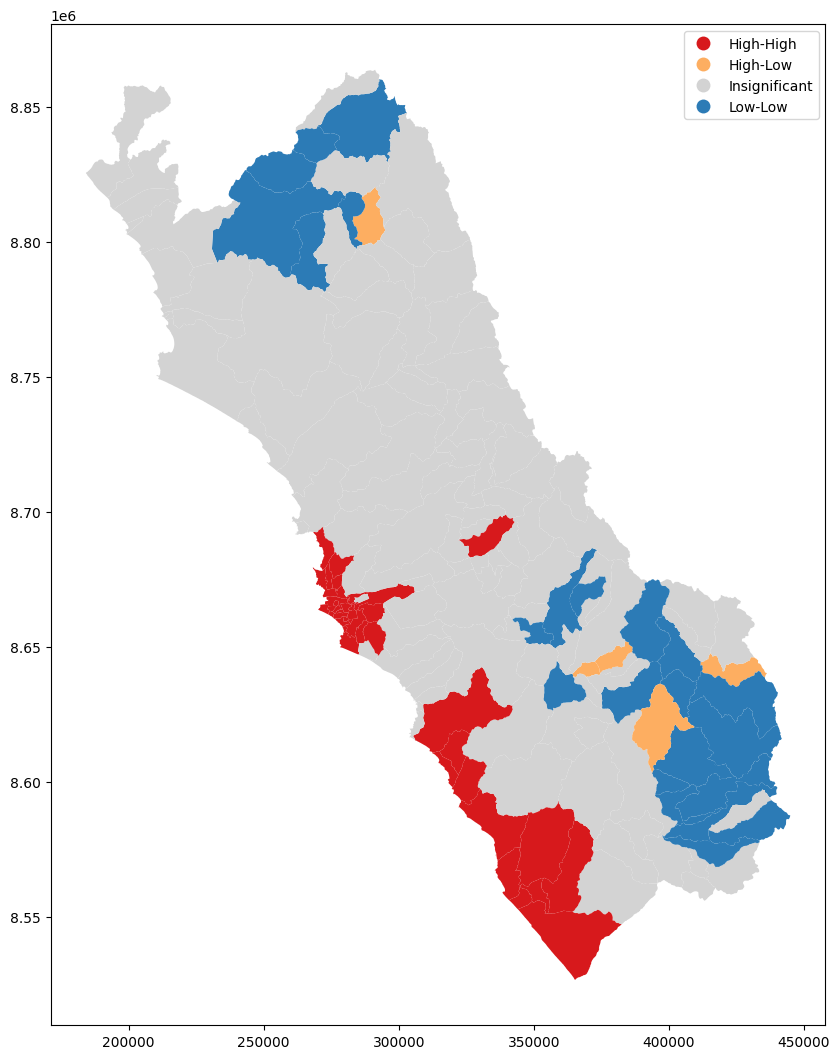

In [5]:
lisaQueen = esda.Moran_Local(lima['Educ_sec_comp2019_pct'], limaQueen, seed = 454786) # get moran I calcs
lisaQueen.plot(lima,crit_value=0.05,figsize=(10,13),legend=True) # plot it

Now lets get the Moran I quadrants and re-name them:

In [6]:
# grab the labels
lima['Lisa_queen'] = lisaQueen.get_cluster_labels(crit_value=0.05)

#create dictionary
prevLabs = ['High-Low', 'Insignificant', 'Low-Low', 'High-High', 'Low-High']
newLabs = ['1 hotOutlier', '3 no_pattern','4 coldSpot','2 hotSpot', '5 coldOutlier']
labels = dict(zip(prevLabs, newLabs))

# quick and easy replace
lima.replace({'Lisa_queen': labels}, inplace=True)


,DEPARTAMENTO,PROVINCIA,DISTRITO,ubigeo,Poblacion,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry,Lisa_queen
39,Lima,YAUYOS,ALIS,PE151002,1233,0.646897,69.474298,30.3,6.6,"MULTIPOLYGON (((415396.076 8647591.116, 415450...",1 hotOutlier
40,Lima,YAUYOS,AYAUCA,PE151003,2293,0.544152,43.167400,61.9,57.2,"MULTIPOLYGON (((389530.693 8626520.884, 389743...",3 no_pattern
54,Lima,HUAURA,AMBAR,PE150802,2761,0.316448,42.060097,73.3,60.2,"MULTIPOLYGON (((243293.978 8826436.11, 243328....",4 coldSpot
65,Lima,LIMA,ANCON,PE150102,42124,0.668889,72.117976,21.7,1.1,"MULTIPOLYGON (((281417 8715329, 281397.439 871...",3 no_pattern
71,Lima,OYON,ANDAJES,PE150902,1058,0.488913,71.684369,36.4,28.5,"MULTIPOLYGON (((291522.945 8820149.937, 291499...",1 hotOutlier
...,...,...,...,...,...,...,...,...,...,...,...
1799,Lima,LIMA,VILLA MARIA DEL TRIUNFO,PE150143,473036,0.689812,73.895534,21.9,1.3,"MULTIPOLYGON (((294277.314 8649754.267, 294333...",2 hotSpot
1804,Lima,YAUYOS,VINAC,PE151032,1906,0.353468,48.996169,57.8,45.3,"MULTIPOLYGON (((415274.705 8578168.622, 415429...",4 coldSpot
1813,Lima,YAUYOS,VITIS,PE151033,665,0.515071,58.157218,20.1,13.6,"MULTIPOLYGON (((415484.035 8649162.757, 415430...",3 no_pattern
1850,Lima,YAUYOS,YAUYOS,PE151001,2905,0.578646,68.601779,37.3,17.3,"MULTIPOLYGON (((406970.333 8623705.927, 406944...",1 hotOutlier


Now lets do the same but for KNN:

<Axes: >

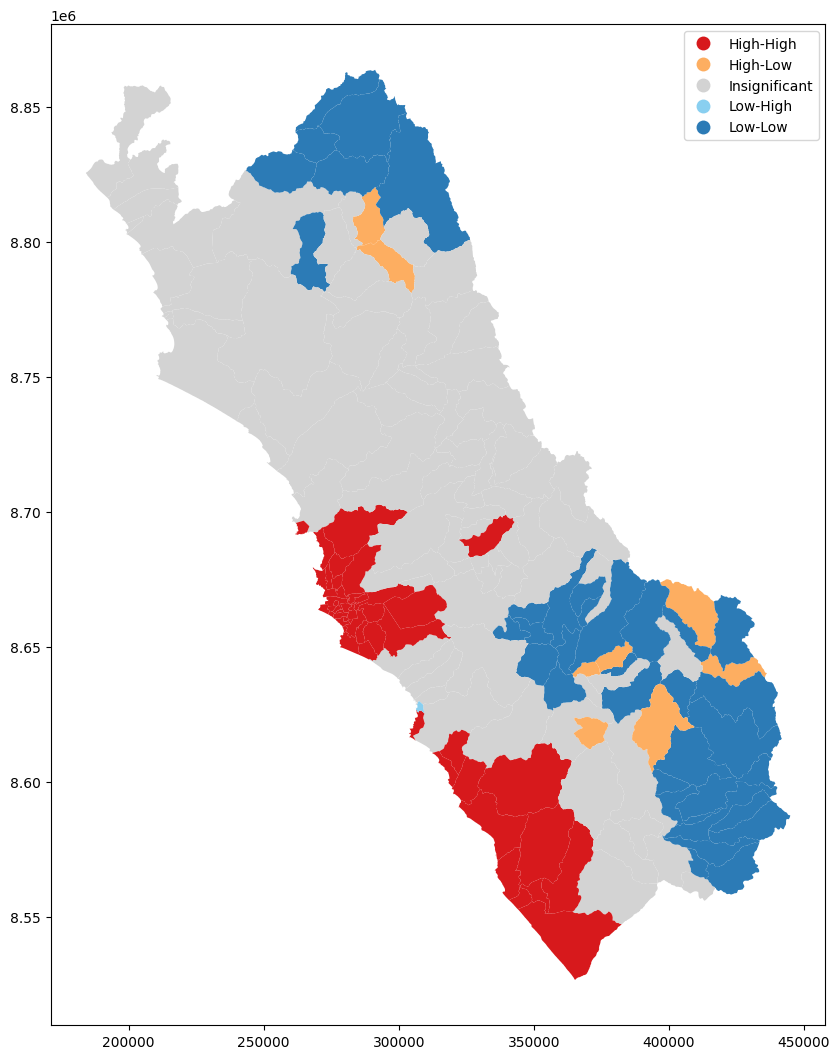

In [7]:
# get ref points for KNN to use
limaRefPoints = lima.representative_point()

# build graph object and normalize
LimaKNN = Graph.build_knn(limaRefPoints,k=8)
LimaKNN=LimaKNN.transform("r")

#get moran I quadrant calcs
lisaKNN = esda.Moran_Local(lima['Educ_sec_comp2019_pct'], LimaKNN, seed = 454786)
lima['Lisa_knn8'] = lisaKNN.get_cluster_labels(crit_value=0.05)

# build dictionary to swap 
prevLabs = ['High-Low', 'Insignificant', 'Low-Low', 'High-High', 'Low-High']
newLabs = ['1 hotOutlier', '3 no_pattern','4 coldSpot','2 hotSpot', '5 coldOutlier']
labels = dict(zip(prevLabs, newLabs))

# replace the values
lima.replace({'Lisa_knn8': labels}, inplace=True)

#quick plot to visually compare, and maps are cool
lisaKNN.plot(lima,crit_value=0.05,figsize=(10,13),legend=True)


# Checking for Changes
Now lets see what changed or stayed the same:

In [8]:
changeInvst = lima.copy()
#Did it this way because I was testing things out before I renamed the columns
queen = "Lisa_queen"
knn = "Lisa_knn8"


In [9]:
# overall agreement
agreement = (changeInvst[queen] == changeInvst[knn]).mean() #Bool if they match, then mean to get prop
print(f"Agreement: {agreement:.2%}")

Agreement: 81.29%


In [10]:
# pure changes
changed = changeInvst[changeInvst[queen] != changeInvst[knn]] # dataframe of those that dont match

print(f"Districts that changed group: {len(changed)} of {len(changeInvst)}") #len(changed) = how many changed, changeInvst = ~raw data
print(changed[['DISTRITO', 'PROVINCIA', queen, knn]].sort_values(queen)) # print the district and province of those that changed (district+province = unique key)

Districts that changed group: 32 of 171
                    DISTRITO   PROVINCIA    Lisa_queen      Lisa_knn8
329                   CHILCA      CANETE     2 hotSpot   3 no_pattern
224               CARABAYLLO        LIMA  3 no_pattern      2 hotSpot
315                  CHECRAS      HUAURA  3 no_pattern   1 hotOutlier
390              CIENEGUILLA        LIMA  3 no_pattern      2 hotSpot
396                  COAYLLO      CANETE  3 no_pattern      2 hotSpot
450                     COPA   CAJATAMBO  3 no_pattern     4 coldSpot
479                   CUENCA  HUAROCHIRI  3 no_pattern     4 coldSpot
544                   GORGOR   CAJATAMBO  3 no_pattern     4 coldSpot
557                   HONGOS      YAUYOS  3 no_pattern     4 coldSpot
615                 HUANCAYA      YAUYOS  3 no_pattern   1 hotOutlier
621                   HUANEC      YAUYOS  3 no_pattern     4 coldSpot
622               HUANGASCAR      YAUYOS  3 no_pattern     4 coldSpot
810              LAHUAYTAMBO  HUAROCHIRI  3 no_pat

In [11]:
# Transition Table
transition = (
    changeInvst
    .groupby([queen, knn]) #group by the two algorithms
    .size() #straight count of each
    .reset_index(name="Count") #fix index name
    .sort_values("Count", ascending=False) # sort for beauty
)

#% for each transition
transition["Percent"] = (
    transition["Count"] / len(changeInvst) * 100 #run of the mill % calc
)
print("\nTransitions")
print(transition)


Transitions
     Lisa_queen      Lisa_knn8  Count    Percent
5  3 no_pattern   3 no_pattern     76  44.444444
1     2 hotSpot      2 hotSpot     38  22.222222
9    4 coldSpot     4 coldSpot     20  11.695906
6  3 no_pattern     4 coldSpot     15   8.771930
4  3 no_pattern      2 hotSpot      9   5.263158
0  1 hotOutlier   1 hotOutlier      5   2.923977
8    4 coldSpot   3 no_pattern      3   1.754386
3  3 no_pattern   1 hotOutlier      3   1.754386
2     2 hotSpot   3 no_pattern      1   0.584795
7  3 no_pattern  5 coldOutlier      1   0.584795


In [12]:
pd.crosstab(changeInvst[queen], changeInvst[knn]) #regular crosstab() to get confusion matrix, different representation of the transition table

Lisa_knn8,1 hotOutlier,2 hotSpot,3 no_pattern,4 coldSpot,5 coldOutlier
Lisa_queen,,,,,
1 hotOutlier,5,0,0,0,0
2 hotSpot,0,38,1,0,0
3 no_pattern,3,9,76,15,1
4 coldSpot,0,0,3,20,0


In [13]:
# Cohen's kappa (because its not a real test without a statistical test, and lets test the inter-rater reliability)
kappa = cohen_kappa_score( 
    changeInvst[queen],
    changeInvst[knn]
)
print(f"\nCohen's Kappa: {kappa:.3f}")


Cohen's Kappa: 0.700


> Note: A did do some cusory googling on the geography of Lima, but I may make mistakes. 

Of the 171 districts in the Lima department, 139 (81.3%) received the same LISA classification under both the Queen contiguity weights and the KNN(8) weights, and 32 (18.7%) changed groups. Cohen's Kappa is 0.70, indicating  agreement beyond what chance alone would produce.

The direction of the disagreement is one-sided. Every one of the 32 changes involves the `3 no_pattern` category on one side; no district ever flipped between opposite cluster types (no hotSpot to coldSpot, and no spot outlier reversals).

This pattern is derived from how the two weights matrices are built. Queen contiguity gives each district only the neighbors it physically touches, often just 3–6, and fewer still for the elongated rural districts or districts that are entirely inside one other district. KNN instead forces every district to have exactly 8 neighbors (k=8), stretching neighborhoods over larger distances in sparse areas. Averaging the spatial lag over more (and farther) neighbors smoothing the lag, which pushes borderline districts past the 0.05 significance threshold (I think of this as sharing the love).

Conclusion: the answer to the question is yes, 32 districts do not belong to the same group under the two criteria. However, the disagreement is largely confined to the margins of statistical significance. The cores of the high education clusters (metropolitan Lima) and low-education clusters (rural highland provinces) remain unchanged.

